# Monitor a fit

`loss_monitor` chooses the loss used for early stopping and for saving the
best fit. Choose it when creating {py:class}`liesel.optim.LieselOptim`.

| Setting | Use it when | What is measured |
| --- | --- | --- |
| `"validation"` | You have held-out validation data. | Full validation loss after each epoch. |
| `"train_full_data"` | You want to check the full training objective. | Full training loss after each epoch. |
| `opt.EmaTrainLossMonitor(effective_window=2.0)` | Full-data checks are too expensive. | A running average of minibatch training losses. |

An epoch runs all configured batches. The two full-data monitors each add one
loss evaluation at the end of every epoch. Validation uses likelihood only by
default; set `validation_strategy="log_prob"` to include priors.

The examples assume a Gaussian regression `model` with observed `X` and `y`,
as in the {doc}`first tutorial <tutorials/notebooks/09-liesel-optim-basic>`.

In [1]:
import logging

import jax.numpy as jnp
import numpy as np
import optax
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

In [2]:
logging.getLogger("liesel").setLevel(logging.WARNING)

rng = np.random.default_rng(42)
x = np.linspace(-1.0, 1.0, 128)

X = lsl.Var.new_obs(jnp.asarray(x), name="X")
beta = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, 0.0, 5.0),
    name="beta",
)

log_sigma = lsl.Var.new_param(0.0, name="log_sigma")
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")

mu = lsl.Var.new_calc(
    lambda X, beta: X * beta,
    X,
    beta,
    name="mu",
)

y = lsl.Var.new_obs(
    jnp.asarray(0.5 * x + rng.normal(scale=0.7, size=x.size)),
    dist=lsl.Dist(tfd.Normal, mu, sigma),
    name="y",
)
model = lsl.Model(y)

## Choose when to stop

In [3]:
stopper = opt.Stopper(epochs=500, patience=20, rtol=1e-4)

builder = opt.LieselOptim(
    model,
    optimizers=optax.adam(0.01),
    loss_monitor="train_full_data",
    stopper=stopper,
    show_progress=False,
)

result = builder.fit()

This allows at most 500 epochs. Within the last 20 epochs, fitting stops when
there is no worthwhile improvement over the oldest loss in that window.
`atol` measures absolute improvement; `rtol` measures relative improvement.
See {py:class}`~liesel.optim.Stopper` for the exact rule.

## Read the result

In [4]:
result.status

'early_stopping'

In [5]:
result.position_min_monitor

{'beta': Array(0.43896037, dtype=float32, weak_type=True),
 'log_sigma': Array(-0.5868051, dtype=float32, weak_type=True)}

* {attr}`result.position_min_monitor <liesel.optim.OptimResult.position_min_monitor>` holds the parameters saved at the epoch with
  the lowest finite monitoring loss. It raises `RuntimeError` if no such loss
  was recorded. An earlier best position remains available after a later failure.
* {attr}`result.position_final <liesel.optim.OptimResult.position_final>` holds the parameters at the end of the run.
* Stateful losses expose matching {attr}`result.loss_state_min_monitor <liesel.optim.OptimResult.loss_state_min_monitor>` and
  {attr}`result.loss_state_final <liesel.optim.OptimResult.loss_state_final>` snapshots. These are `None` for stateless losses
  or when no matching full-training evaluation exists.
* {meth}`result.plot_loss_overview() <liesel.optim.OptimResult.plot_loss_overview>` shows the full loss history and a closer
  view of recent epochs.
* {meth}`result.plot_params() <liesel.optim.OptimResult.plot_params>` shows saved parameter paths.

Both position properties raise `RuntimeError` if their parameters contain NaN
or infinity. History, status, and diagnostics remain available for inspection.
See {ref}`optimizer-debug-nans` to capture information about a NaN failure.

The training curve averages the losses seen before each update. Parameters
change during an epoch, so this curve is not the full training loss at its end.
Use {meth}`result.history.loss_df() <liesel.optim.OptimHistory.loss_df>` to inspect the recorded values.

In [6]:
result.history.loss_df().tail().round(4)

,epoch,loss_train,loss_monitor
93,93.0,0.8518,0.8518
94,94.0,0.8518,0.8518
95,95.0,0.8518,0.8518
96,96.0,0.8518,0.8518
97,97.0,0.8518,0.8518


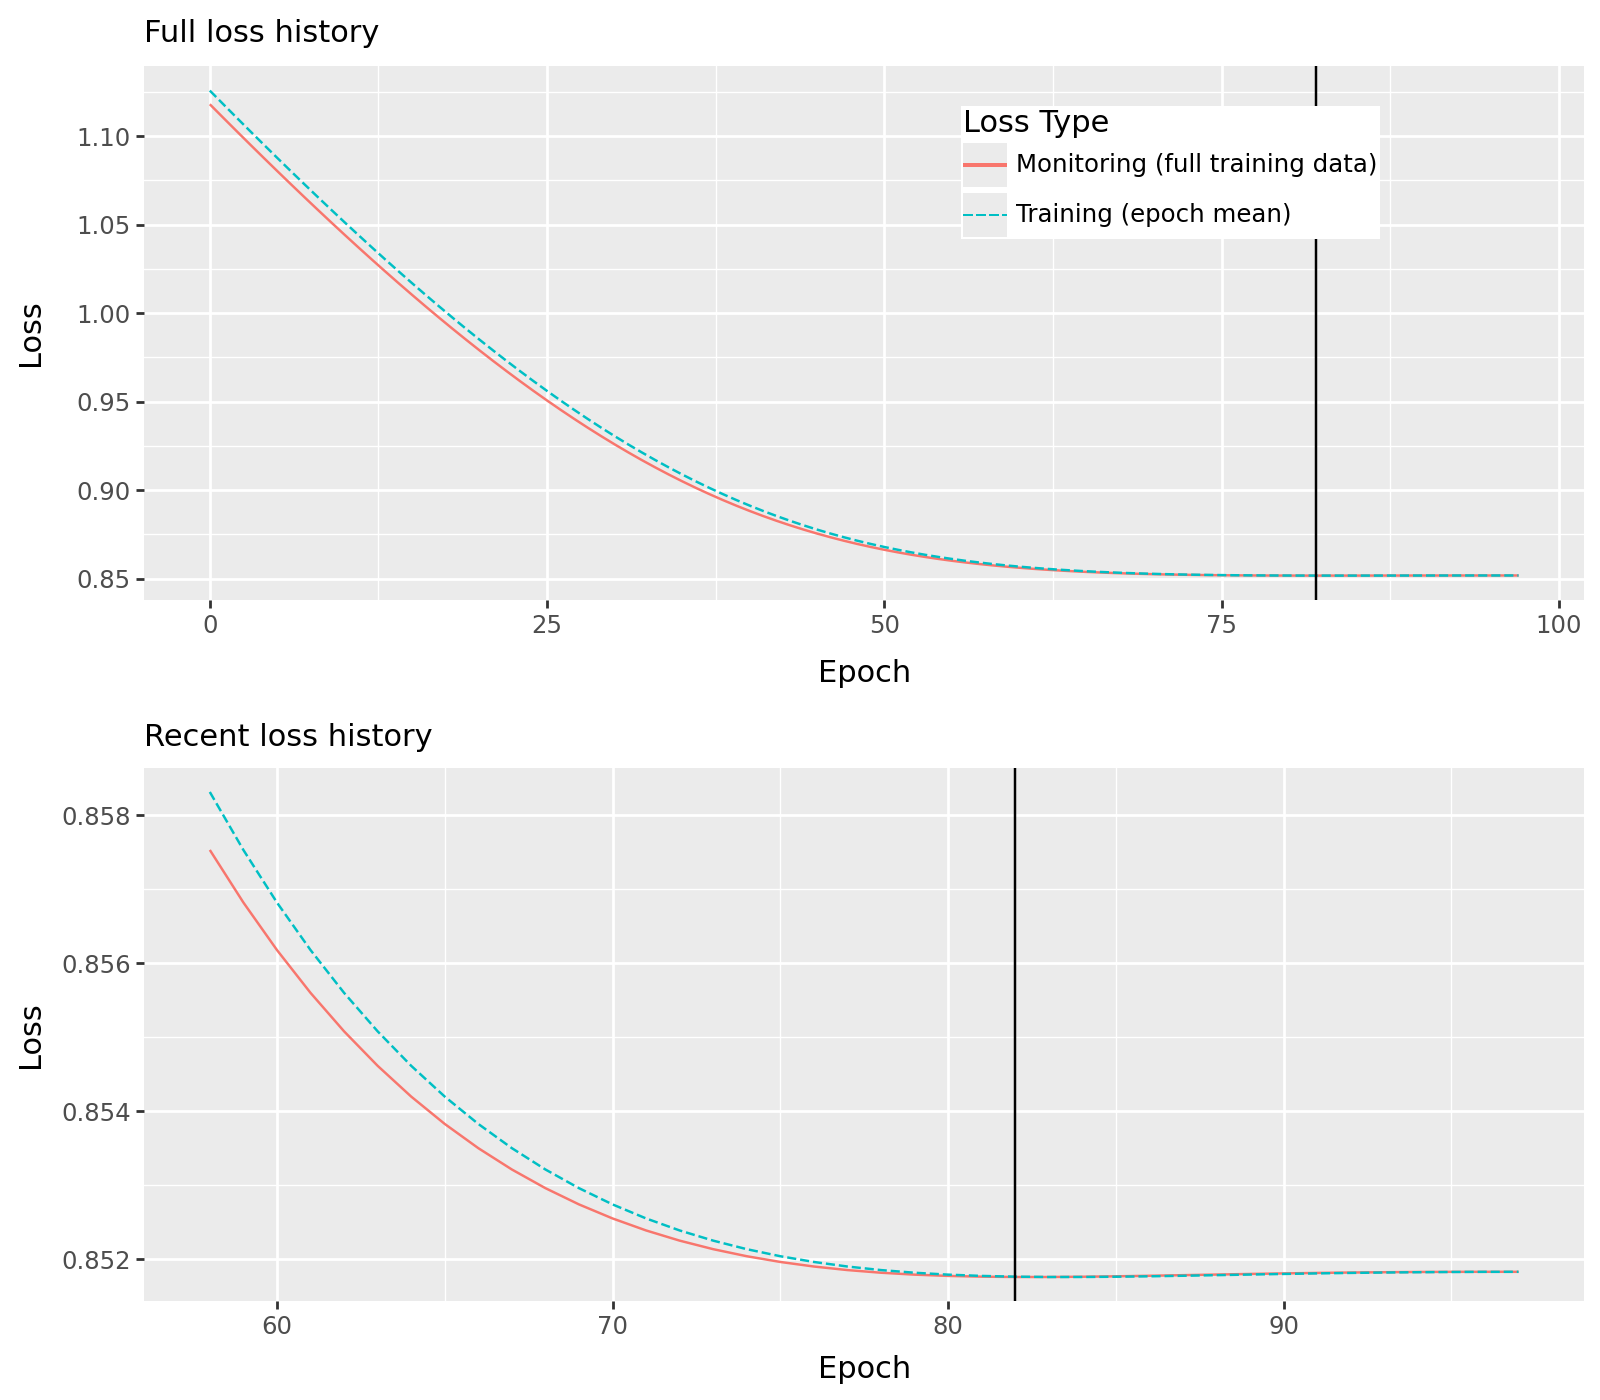

In [7]:
result.plot_loss_overview()

The overview shows the initial improvement and recent convergence. A flat curve
does not by itself establish that the parameters are at an exact optimum.

## Smooth noisy losses

Reuse the same model with minibatches and an EMA monitor:

In [8]:
result = opt.LieselOptim(
    model,
    optimizers=optax.adam(0.01),
    batch_size=32,
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=2.0),
    stopper=stopper,
    show_progress=False,
    seed=42,
).fit()

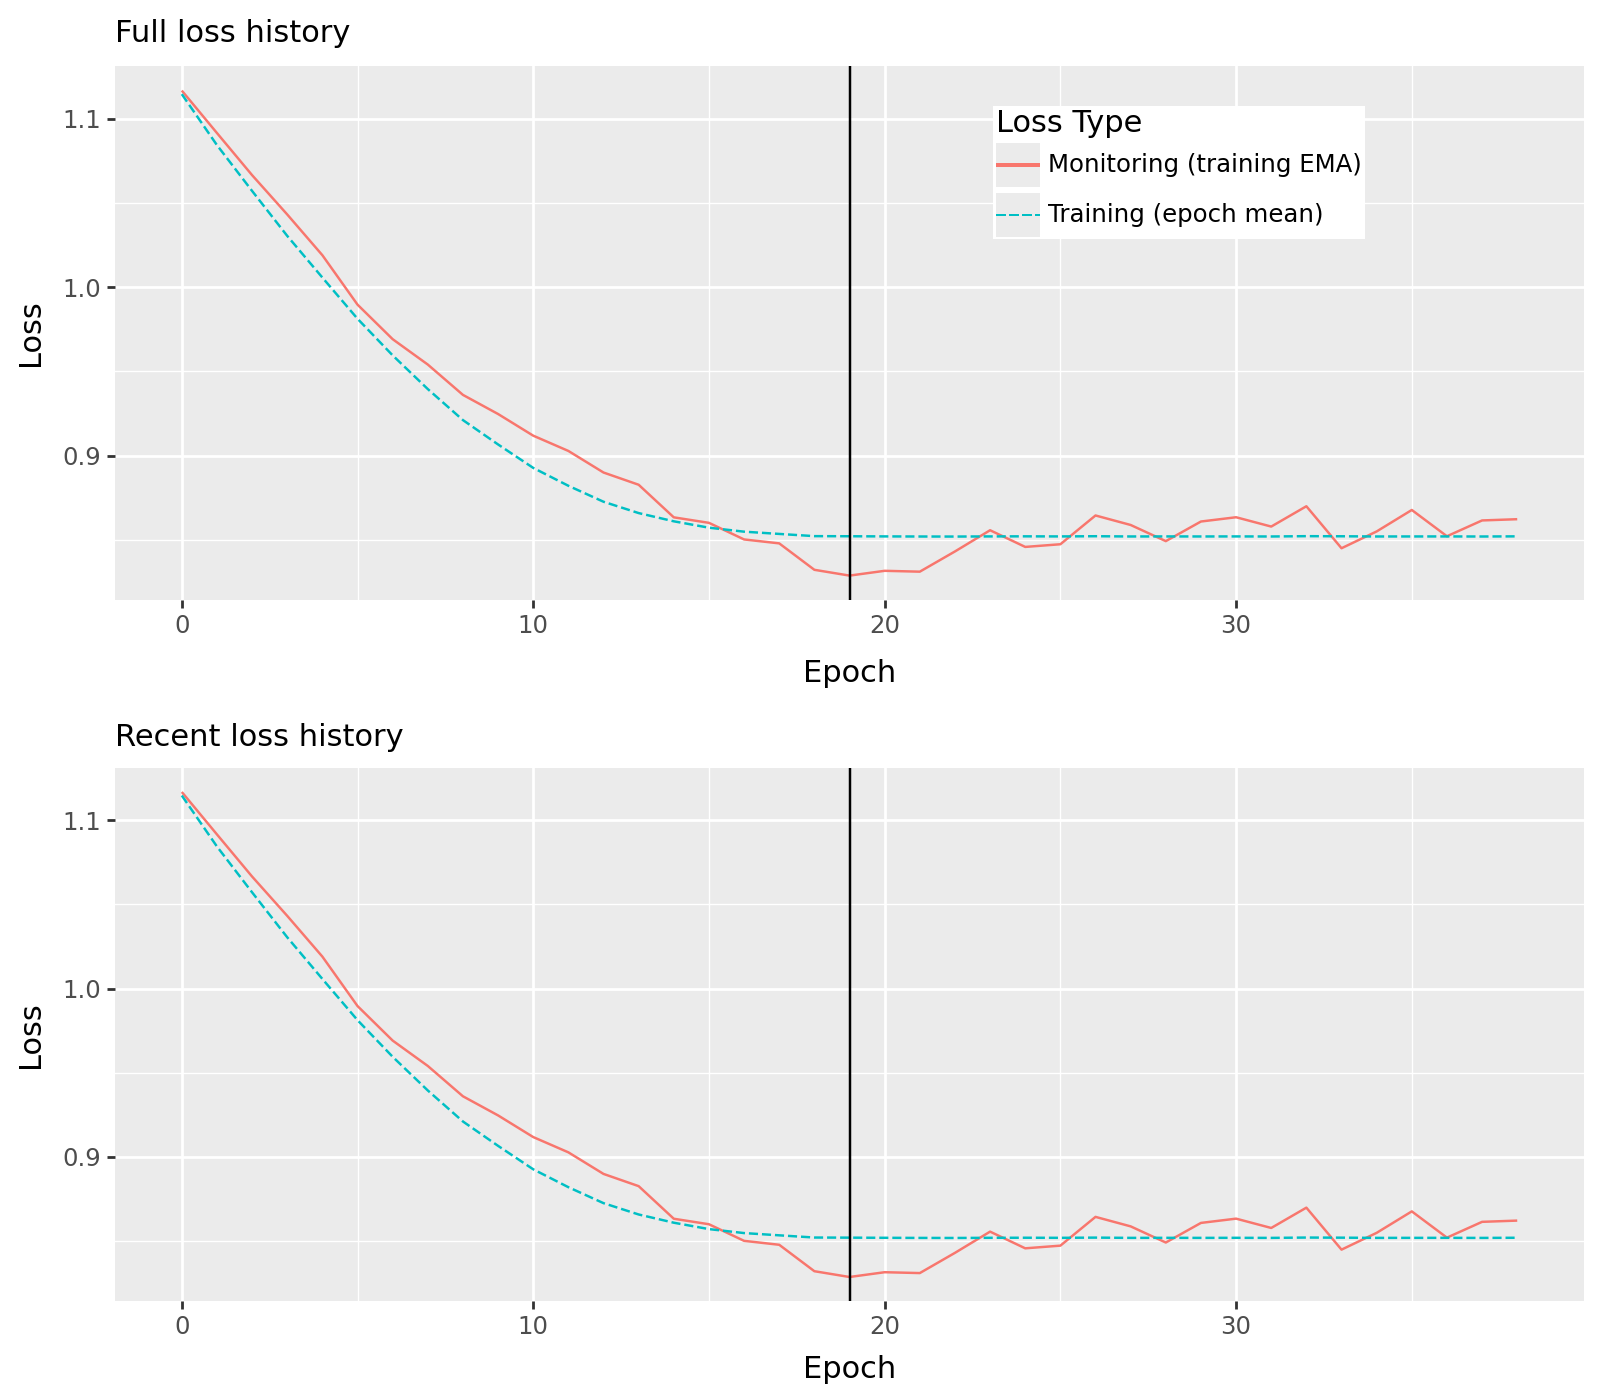

In [9]:
result.plot_loss_overview()

A larger `effective_window` smooths more and reacts more slowly. Its unit is
an epoch's worth of batches. Older losses fade gradually; they are not dropped
at a fixed age. The average continues across epochs and reuses losses already
computed for optimizer updates.

Because the average still includes older losses, it trails the current loss a
little. The delay is about half the window: with `effective_window=2.0`, about
one epoch. The default stopper of `LieselOptim` waits 10 epochs for an
improvement, and the stopper above waits 20, so this delay makes little
difference. Increase the window only if the monitored loss still jumps around
near the end of the fit, and keep the delay well below how long the stopper
waits.

An EMA combines losses from several parameter positions. Its best saved position
is the snapshot at the end of that epoch; its exact loss need not equal the
EMA monitor value. See {py:class}`~liesel.optim.EmaTrainLossMonitor` for the formula
and the alternative {py:meth}`~liesel.optim.EmaTrainLossMonitor.from_half_life` setting.

(optimizer-debug-nans)=

## Investigate NaNs

For a configured {class}`LieselOptim <liesel.optim.LieselOptim>` builder, enable first-NaN reproduction capture
on its engine before fitting:

In [10]:
engine = builder.build_engine()
engine.debug_nans = True
result = engine.fit()
debug_info = result.nan_debug

In [11]:
debug_info is None

True

If a NaN is detected, `debug_info` contains information for reproducing it;
otherwise it is `None`. See {py:class}`~liesel.optim.OptimNaNDebugInfo` for its
contents. The captured information helps investigate the failure; it does
not correct poor starting values.

{class}`LaplaceLoss <liesel.optim.LaplaceLoss>` reports inner or outer numerical failures through
`status="numerical_failure"`, `failure_reason`, and {attr}`failed_loss_state <liesel.optim.OptimResult.failed_loss_state>`.
See {ref}`optimizer-laplace-failure` for an example and recovery behavior.